## Predicting Sleep Disruption and Attention Fragmentation from Smartphone Usage Patterns

##### The Problem: Excessive smartphone usage—especially late-night screen exposure and frequent interruptions—has been linked to disrupted sleep cycles and reduced attention span. Behavioral patterns such as prolonged screen time, high notification frequency, and irregular usage habits can negatively impact sleep quality and cognitive performance.
##### The Goal: This project aims to analyze smartphone usage patterns and build machine learning models to:predict sleep disruption levels using regression techniques --classify attention fragmentation levels (low, moderate, high) using classification methods.    This enables identification of usage behaviors that contribute to poor sleep and reduced focus.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Loading Dataset:**
###### URL : https://www.kaggle.com/datasets/jayjoshi37/sleep-screen-time-and-stress-analysis
##### The dataset used in this project is a publicly available behavioral dataset containing 15,000 records representing individuals with different smartphone usage habits, sleep patterns, and lifestyle factors.

In [2]:
df = pd.read_csv("../data/sleep_mobile.csv")
df.head(10)

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,F,designer,3.26,86.0,5.31 hrs,7.72,3.49,0,35,119.0,3.57
1,2,46,F,TEACHER,1.85,32.0,7.36 hrs,9.70,3.01,0,16,299.0,1.91
2,3,32,male,designer,3.04,107.0,4.5 hrs,6.38,5.03,0,17,21.0,6.05
3,4,25,male,SOFTWARE ENGINEER,9.0 hrs,NaN,6.68 hrs,5.53,10.00,0,3,220.0,9.92
4,5,38,F,teacher,3.52,56.0,7.57 hrs,6.69,6.71,4,92,167.0,5.99
5,6,56,M,teacher,7.26,NaN,7.79 hrs,6.16,10.00,2,50 min,NaN,7.85
6,7,36,F,teacher,4.56,83.0,6.81 hrs,6.81,5.38,0,19,39.0,5.52
7,8,40,M,manager,3.36,89.0,6.5 hrs,8.75,3.48,2,66,127.0,4.50
8,9,28,M,STUDENT,approx 2.3,109.0,7.57 hrs,8.05,3.46,3,103,99.0,2.52
9,10,28,F,manager,9.75,46.0,4.73 hrs,5.52,10.00,3,56,121.0,10.00


## **Data Overview:**

In [3]:
df.shape

(15300, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15300 entries, 0 to 15299
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15300 non-null  int64  
 1   age                               15300 non-null  int64  
 2   gender                            15300 non-null  object 
 3   occupation                        15300 non-null  object 
 4   daily_screen_time_hours           14734 non-null  object 
 5   phone_usage_before_sleep_minutes  14826 non-null  float64
 6   sleep_duration_hours              15300 non-null  object 
 7   sleep_quality_score               14508 non-null  float64
 8   stress_level                      14634 non-null  float64
 9   caffeine_intake_cups              15300 non-null  int64  
 10  physical_activity_minutes         15300 non-null  object 
 11  notifications_received_per_day    14902 non-null  float64
 12  ment

In [5]:
df.head(10)

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,F,designer,3.26,86.0,5.31 hrs,7.72,3.49,0,35,119.0,3.57
1,2,46,F,TEACHER,1.85,32.0,7.36 hrs,9.70,3.01,0,16,299.0,1.91
2,3,32,male,designer,3.04,107.0,4.5 hrs,6.38,5.03,0,17,21.0,6.05
3,4,25,male,SOFTWARE ENGINEER,9.0 hrs,NaN,6.68 hrs,5.53,10.00,0,3,220.0,9.92
4,5,38,F,teacher,3.52,56.0,7.57 hrs,6.69,6.71,4,92,167.0,5.99
5,6,56,M,teacher,7.26,NaN,7.79 hrs,6.16,10.00,2,50 min,NaN,7.85
6,7,36,F,teacher,4.56,83.0,6.81 hrs,6.81,5.38,0,19,39.0,5.52
7,8,40,M,manager,3.36,89.0,6.5 hrs,8.75,3.48,2,66,127.0,4.50
8,9,28,M,STUDENT,approx 2.3,109.0,7.57 hrs,8.05,3.46,3,103,99.0,2.52
9,10,28,F,manager,9.75,46.0,4.73 hrs,5.52,10.00,3,56,121.0,10.00


In [6]:
print("Dataset shape:")
print(df.shape)
print("\n")
print("Dataset info:")
print(df.info())

Dataset shape:
(15300, 13)


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15300 entries, 0 to 15299
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15300 non-null  int64  
 1   age                               15300 non-null  int64  
 2   gender                            15300 non-null  object 
 3   occupation                        15300 non-null  object 
 4   daily_screen_time_hours           14734 non-null  object 
 5   phone_usage_before_sleep_minutes  14826 non-null  float64
 6   sleep_duration_hours              15300 non-null  object 
 7   sleep_quality_score               14508 non-null  float64
 8   stress_level                      14634 non-null  float64
 9   caffeine_intake_cups              15300 non-null  int64  
 10  physical_activity_minutes         15300 non-null  object 
 11  notifications_received_p

In [7]:
print(df.dtypes)

user_id                               int64
age                                   int64
gender                               object
occupation                           object
daily_screen_time_hours              object
phone_usage_before_sleep_minutes    float64
sleep_duration_hours                 object
sleep_quality_score                 float64
stress_level                        float64
caffeine_intake_cups                  int64
physical_activity_minutes            object
notifications_received_per_day      float64
mental_fatigue_score                float64
dtype: object


In [8]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,15300.0,NaN,NaN,NaN,7504.068889,4331.669102,1.0,3751.75,7509.5,11253.25,15000.0
age,15300.0,NaN,NaN,NaN,38.493856,12.005441,18.0,28.0,38.0,49.0,59.0
gender,15300,4,M,5156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,15300,18,manager,1371,NaN,NaN,NaN,NaN,NaN,NaN,NaN
daily_screen_time_hours,14734,2599,20.0,107,NaN,NaN,NaN,NaN,NaN,NaN,NaN
phone_usage_before_sleep_minutes,14826.0,NaN,NaN,NaN,59.639822,34.637734,0.0,29.0,60.0,90.0,119.0
sleep_duration_hours,15300,954,8.09 hrs,49,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_quality_score,14508.0,NaN,NaN,NaN,6.251327,1.713381,1.0,5.01,6.25,7.5,10.0
stress_level,14634.0,NaN,NaN,NaN,6.969721,2.752545,1.0,4.74,7.37,10.0,10.0
caffeine_intake_cups,15300.0,NaN,NaN,NaN,2.000065,1.414699,0.0,1.0,2.0,3.0,4.0


In [9]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col} — {df[col].nunique()} unique values:")
    print(df[col].value_counts().head(10))


gender — 4 unique values:
gender
M        5156
F        5128
male     4605
Other     411
Name: count, dtype: int64

occupation — 18 unique values:
occupation
manager              1371
doctor               1351
freelancer           1346
software engineer    1305
student              1280
researcher           1277
designer             1250
teacher              1245
SOFTWARE ENGINEER     600
MANAGER               587
Name: count, dtype: int64

daily_screen_time_hours — 2599 unique values:
daily_screen_time_hours
20.0        107
20.0 hrs     30
5.33         25
2.22         25
2.52         22
5.62         22
5.43         22
5.5          21
6.87         21
2.58         21
Name: count, dtype: int64

sleep_duration_hours — 954 unique values:
sleep_duration_hours
8.09 hrs    49
8.6 hrs     46
8.08 hrs    44
7.53 hrs    44
5.5 hrs     43
8.92 hrs    42
8.83 hrs    42
6.41 hrs    41
6.17 hrs    41
8.04 hrs    40
Name: count, dtype: int64

physical_activity_minutes — 240 unique values:
physical_a

## **Missing Values Analysis:**

In [10]:
# Total missing per column
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_percent': missing_pct.round(2)
}).sort_values('missing_percent', ascending=False)

print(missing_df)

                                  missing_count  missing_percent
sleep_quality_score                         792             5.18
stress_level                                666             4.35
mental_fatigue_score                        627             4.10
daily_screen_time_hours                     566             3.70
phone_usage_before_sleep_minutes            474             3.10
notifications_received_per_day              398             2.60
user_id                                       0             0.00
age                                           0             0.00
gender                                        0             0.00
occupation                                    0             0.00
sleep_duration_hours                          0             0.00
caffeine_intake_cups                          0             0.00
physical_activity_minutes                     0             0.00


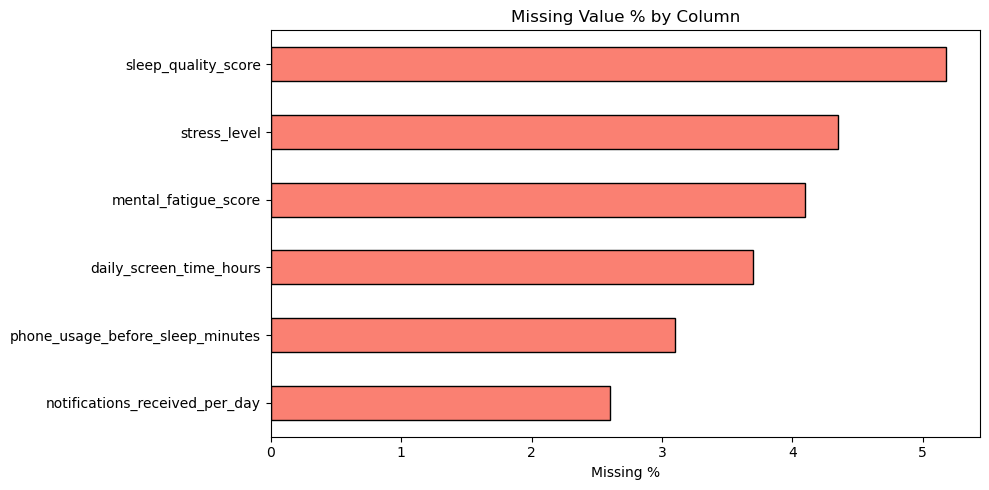

In [11]:
plt.figure(figsize=(10, 5))
missing_df[missing_df['missing_count'] > 0]['missing_percent'].sort_values().plot(
    kind='barh', color='salmon', edgecolor='black'
)
plt.title('Missing Value % by Column')
plt.xlabel('Missing %')
plt.tight_layout()
plt.show()

In [12]:
# Check for empty strings hiding as non-null
for col in df.select_dtypes(include='object').columns:
    empty = (df[col].str.strip() == '').sum()
    if empty > 0:
        print(f"{col}: {empty} empty strings")

In [13]:
# Create a column that flags whether sleep_quality_score is missing
df['sq_missing'] = df['sleep_quality_score'].isnull().astype(int)

# Compare other columns between missing and non-missing groups
print(df.groupby('sq_missing')[['stress_level','mental_fatigue_score','phone_usage_before_sleep_minutes']].mean())

# Clean up the temporary column after
df.drop(columns=['sq_missing'], inplace=True)

            stress_level  mental_fatigue_score  \
sq_missing                                       
0               6.972509              6.871766   
1               6.919506              6.819802   

            phone_usage_before_sleep_minutes  
sq_missing                                    
0                                  59.635238  
1                                  59.723157  


In [14]:
# How many rows have MORE than one missing value?
rows_with_multiple_missing = (df.isnull().sum(axis=1) > 1).sum()
print(f"Rows missing more than one value: {rows_with_multiple_missing}")

# Distribution — how many columns are missing per row?
print(df.isnull().sum(axis=1).value_counts().sort_index())

Rows missing more than one value: 278
0    12072
1     2950
2      261
3       17
Name: count, dtype: int64


- Missing value analysis shows that null rates range from 2.6% to 5.18% across 6 columns.
- Group-wise comparison confirms values are Missing Completely At Random (MCAR)
- mean values of related columns are nearly identical between missing and non-missing groups.
- 278 rows have multiple missing values, with only 17 rows missing 3+ columns simultaneously.
- Since missingness is random and low in volume, median/mean imputation is a valid strategy.

### Executing Missing Value Treatment

### What we are doing:
Based on our missing value analysis, we now apply the decided imputation strategy.
The approach differs by column type and role in the model.

### Why we are doing it this way:

**Dropping rows (mental_fatigue_score):**
mental_fatigue_score is our target variable — the value the ML model will learn to predict.
Imputing a target variable means fabricating the answer, which would directly corrupt
model training. So any row where the target is missing is simply removed.

**Median imputation (all other numeric columns):**
All 6 affected columns showed MCAR (Missing Completely At Random) behavior —
confirmed by comparing group means between missing and non-missing rows, which were
nearly identical. Since outlier treatment has not been performed yet, median is chosen
over mean because median is resistant to extreme values and gives a more representative
center for skewed distributions.

**daily_screen_time_hours is skipped here:**
This column is currently stored as object (string) dtype instead of numeric.
Computing a median on string data is not valid.

### Alternatives we considered:
- Dropping all rows with any null: would remove ~2950 rows (19% of data) unnecessarily,
  losing valuable information when we can safely impute instead.

In [15]:
# See ALL unique values in occupation
print(df['occupation'].str.lower().str.strip().value_counts())
print(f"\nTotal unique after lowercasing: {df['occupation'].str.lower().str.strip().nunique()}")

occupation
manager              1958
software engineer    1905
doctor               1901
freelancer           1887
student              1845
researcher           1807
designer             1805
teacher              1760
unknown               432
Name: count, dtype: int64

Total unique after lowercasing: 9


### What we found:
The occupation column showed 0 null values in standard missing value checks.
However, manual inspection revealed 432 rows containing the string "unknown" —
a disguised missing value that isnull() cannot detect.

### What we are doing:
Rather than replacing "unknown" with the mode occupation, we retain it as a
valid category. With 432 instances (2.82% of data), this group is large enough
to potentially represent a distinct behavioral pattern in smartphone usage.
Overwriting it with the most frequent occupation would introduce false information.


In [16]:
# 1. Drop rows where target variable is missing
df.dropna(subset=['mental_fatigue_score'], inplace=True)
print(f"Rows after dropping missing target: {len(df)}")

# 2. Impute numeric columns with median
cols_to_impute = [
    'sleep_quality_score',
    'stress_level',
    'phone_usage_before_sleep_minutes',
    'notifications_received_per_day'
]

for col in cols_to_impute:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"{col}: imputed with median = {median_val:.3f}")

# 3. Fix occupation — lowercase + strip + capitalize properly
df['occupation'] = df['occupation'].str.lower().str.strip().str.title()
print(f"\nOccupation unique values after fix: {df['occupation'].nunique()}")
print(df['occupation'].value_counts())

# 4. Confirm remaining nulls
print("\nRemaining nulls after Step 2:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Rows after dropping missing target: 14673
sleep_quality_score: imputed with median = 6.250
stress_level: imputed with median = 7.360
phone_usage_before_sleep_minutes: imputed with median = 60.000
notifications_received_per_day: imputed with median = 162.000

Occupation unique values after fix: 9
occupation
Manager              1891
Software Engineer    1828
Freelancer           1819
Doctor               1818
Student              1765
Researcher           1728
Designer             1726
Teacher              1687
Unknown               411
Name: count, dtype: int64

Remaining nulls after Step 2:
daily_screen_time_hours    544
dtype: int64


/var/folders/5w/40v6y__153s245ll58v9krdw0000gn/T/ipykernel_32204/2969623827.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


### Summary of Changes

- Dropped 627 rows where mental_fatigue_score (target variable) was null.
  Dataset reduced from 15,300 → 14,673 rows.
- Imputed 4 numeric columns with median values (MCAR confirmed, median
  chosen over mean as outlier treatment not yet performed).
- Fixed occupation column: lowercased + title-cased, collapsing 18 apparent
  categories to 9 real ones. "Unknown" retained as a valid category (411 rows).
- daily_screen_time_hours intentionally left with 544 nulls — requires
  dtype conversion before imputation is valid.

## **Duplicate Detection:**

In [17]:
# Finding Number of Duplicates

total_dupes = df.duplicated().sum()
print(f"Total fully duplicate rows: {total_dupes}")

# Also check what % of data this represents
print(f"That is {(total_dupes/len(df)*100):.2f}% of the dataset")

Total fully duplicate rows: 147
That is 1.00% of the dataset


In [18]:
# Show the duplicate rows (keep=False marks ALL copies, not just the second)
dupes = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())
print(f"Shape of duplicate rows dataframe: {dupes.shape}")
dupes.head(10)

Shape of duplicate rows dataframe: (294, 13)


,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
70,71,57,M,Software Engineer,6.17,118.0,7.94 hrs,6.07,8.04,1,44,28.0,8.05
15138,71,57,M,Software Engineer,6.17,118.0,7.94 hrs,6.07,8.04,1,44,28.0,8.05
89,90,34,F,Software Engineer,7.55,58.0,8.47 hrs,3.50,10.00,4,10,92.0,9.55
15231,90,34,F,Software Engineer,7.55,58.0,8.47 hrs,3.50,10.00,4,10,92.0,9.55
142,143,49,male,Freelancer,8.13,119.0,6.82 hrs,5.73,10.00,3,50,49.0,9.63
15128,143,49,male,Freelancer,8.13,119.0,6.82 hrs,5.73,10.00,3,50,49.0,9.63
209,210,26,F,Designer,6.53,52.0,8.15 hours,4.59,7.36,0,25,151.0,9.07
15047,210,26,F,Designer,6.53,52.0,8.15 hours,4.59,7.36,0,25,151.0,9.07
319,320,49,F,Researcher,1.47 hrs,17.0,7.31 hrs,10.00,1.00,2,106,77.0,1.00
15035,320,49,F,Researcher,1.47 hrs,17.0,7.31 hrs,10.00,1.00,2,106,77.0,1.00


In [19]:
# Same user_id appearing multiple times would be suspicious
print("Duplicate user_ids:")
print(df['user_id'].duplicated().sum())

# Check if same user_id has different values (inconsistent records)
print("\nUnique user_ids:", df['user_id'].nunique())
print("Total rows:", len(df))

Duplicate user_ids:
271

Unique user_ids: 14402
Total rows: 14673


### What we found:
- 147 fully duplicate rows (1.00% of dataset) — identical values across all 13 columns.
  These are safe to drop, retaining the first occurrence.
- 271 duplicate user_ids detected, of which 147 are full duplicates.
  The remaining 124 rows share a user_id but contain different values —
  these are inconsistent records representing a data integrity issue,
  not simple duplicates.

### What we will do:
- Drop 147 fully identical rows using df.drop_duplicates().
- Investigate 124 inconsistent user_id records before deciding treatment.

In [20]:
# Find user_ids that appear more than once
duped_ids = df[df['user_id'].duplicated(keep=False)]

# Show only those where rows are NOT fully identical (the dangerous ones)
inconsistent = duped_ids[~duped_ids.duplicated(keep=False)]
print(f"Same user_id, different values: {len(inconsistent)} rows")
print(inconsistent.sort_values('user_id').head(10))

Same user_id, different values: 248 rows
       user_id  age gender  occupation daily_screen_time_hours  \
14          15   20      M    Designer              approx 5.9   
15225       15   20      M    Designer                     5.9   
15214      163   20      F     Student                    6.62   
162        163   20      F     Student                    6.62   
15127      257   41      F  Researcher                    5.11   
256        257   41      F  Researcher                    5.11   
274        275   53      F      Doctor                9.34 hrs   
15017      275   53      F      Doctor                9.34 hrs   
15105      301   50  Other  Freelancer                5.46 hrs   
300        301   50  Other  Freelancer                     NaN   

       phone_usage_before_sleep_minutes sleep_duration_hours  \
14                                 76.0             6.53 hrs   
15225                              76.0             6.53 hrs   
15214                              92.0 

### What we found:
248 rows share a user_id but appear different. On inspection, the differences
are not genuine data contradictions — they are formatting artifacts:
- "approx 5.9" vs "5.9" in daily_screen_time_hours
- "7.24 hrs" vs "7.24 hours" in sleep_duration_hours
- NaN vs "5.46 hrs" where one copy has a value and the other is missing

### Decision:
- Drop 147 fully identical duplicates now.
- Re-run duplicate detection after dtype fixes.
  The remaining 248 will largely resolve into true duplicates at that point
  and will be dropped in a second pass after dtype fixes.

In [21]:
# Drop fully identical rows, keep first occurrence
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)

print(f"Rows before: {before}")
print(f"Rows after:  {after}")
print(f"Dropped:     {before - after} duplicate rows")

# Confirm no full duplicates remain
print(f"\nFull duplicates remaining: {df.duplicated().sum()}")

Rows before: 14673
Rows after:  14526
Dropped:     147 duplicate rows

Full duplicates remaining: 0


### Summary

- Dropped 147 fully identical duplicate rows using drop_duplicates().
- Dataset reduced from 14,673 → 14,526 rows.
- 248 formatting-caused duplicates intentionally left for second pass
  after Step 4 dtype fixes.

## **Data Type & Formatting Fixes:**

##### Fixing Gender

In [22]:
print("Before fix:")
print(df['gender'].value_counts())

# Standardize gender values
gender_map = {
    'M': 'Male',
    'male': 'Male', 
    'F': 'Female',
    'Other': 'Other'
}
df['gender'] = df['gender'].map(gender_map)

print("\nAfter fix:")
print(df['gender'].value_counts())
print(f"Nulls created: {df['gender'].isnull().sum()}")

Before fix:
gender
M        4899
F        4882
male     4353
Other     392
Name: count, dtype: int64

After fix:
gender
Male      9252
Female    4882
Other      392
Name: count, dtype: int64
Nulls created: 0


##### Fixing Sleep_duration_hours

In [23]:
print("Before fix:")
print(df['sleep_duration_hours'].dtype)
print(df['sleep_duration_hours'].sample(5))

# Strip " hrs" and " hours" and convert to float
df['sleep_duration_hours'] = (
    df['sleep_duration_hours']
    .str.replace(r'\s*(hours|hrs)\s*', '', regex=True)
    .str.strip()
    .astype(float)
)

print("\nAfter fix:")
print(df['sleep_duration_hours'].dtype)
print(df['sleep_duration_hours'].describe())
print(f"Nulls created: {df['sleep_duration_hours'].isnull().sum()}")

Before fix:
object
13217    8.86 hrs
9157     8.25 hrs
5266     4.31 hrs
5178     7.97 hrs
6432     7.07 hrs
Name: sleep_duration_hours, dtype: object

After fix:
float64
count    14526.000000
mean         6.511343
std          1.453829
min          4.000000
25%          5.260000
50%          6.500000
75%          7.800000
max          9.000000
Name: sleep_duration_hours, dtype: float64
Nulls created: 0


##### Fixing physical_activity_minutes

In [24]:
print("Before fix:")
print(df['physical_activity_minutes'].dtype)

# Check what non-numeric patterns exist
mask = pd.to_numeric(df['physical_activity_minutes'], errors='coerce').isna()
print(f"\nNon-numeric values count: {mask.sum()}")
print(df.loc[mask, 'physical_activity_minutes'].value_counts().head(10))

Before fix:
object

Non-numeric values count: 818
physical_activity_minutes
47 min     13
68 min     13
66 min     12
87 min     12
55 min     12
83 min     12
119 min    12
0 min      11
65 min     11
106 min    11
Name: count, dtype: int64


In [25]:
# Fix physical_activity_minutes
df['physical_activity_minutes'] = (
    df['physical_activity_minutes']
    .str.replace(r'\s*min\s*', '', regex=True)
    .str.strip()
    .astype(int)
)

print("After fix:")
print(df['physical_activity_minutes'].dtype)
print(df['physical_activity_minutes'].describe())
print(f"Nulls created: {df['physical_activity_minutes'].isnull().sum()}")

After fix:
int64
count    14526.000000
mean        59.228005
std         34.492819
min          0.000000
25%         29.000000
50%         59.000000
75%         89.000000
max        119.000000
Name: physical_activity_minutes, dtype: float64
Nulls created: 0


##### Fixing Daily_screen_time_hours:

In [26]:
print("Before fix:")
print(df['daily_screen_time_hours'].dtype)

# See all non-numeric patterns
mask = pd.to_numeric(df['daily_screen_time_hours'], errors='coerce').isna()
print(f"\nNon-numeric values count: {mask.sum()}")
print(df.loc[mask, 'daily_screen_time_hours'].value_counts().head(20))

Before fix:
object

Non-numeric values count: 4347
daily_screen_time_hours
20.0 hrs       28
approx 20.0     9
9.15 hrs        9
9.97 hrs        9
9.34 hrs        9
4.15 hrs        8
9.7 hrs         8
9.39 hrs        8
6.52 hrs        8
5.45 hrs        8
7.64 hrs        7
7.46 hrs        7
6.04 hrs        7
6.5 hrs         7
5.64 hrs        7
8.98 hrs        7
8.34 hrs        7
9.83 hrs        7
6.01 hrs        7
6.85 hrs        7
Name: count, dtype: int64


In [27]:
# Step 1 — remove "approx" prefix and "hrs"/"hours" suffix
df['daily_screen_time_hours'] = (
    df['daily_screen_time_hours']
    .str.replace(r'approx\s*', '', regex=True)
    .str.replace(r'\s*(hours|hrs)\s*', '', regex=True)
    .str.strip()
)

# Step 2 — convert to numeric (errors='coerce' turns any remaining 
# unparseable values into NaN rather than crashing)
df['daily_screen_time_hours'] = pd.to_numeric(
    df['daily_screen_time_hours'], errors='coerce'
)

print("After string fix:")
print(df['daily_screen_time_hours'].dtype)
print(f"Nulls after conversion: {df['daily_screen_time_hours'].isnull().sum()}")
print(df['daily_screen_time_hours'].describe())

After string fix:
float64
Nulls after conversion: 542
count    13984.000000
mean         5.645639
std          2.960530
min          1.000000
25%          3.280000
50%          5.550000
75%          7.840000
max         20.000000
Name: daily_screen_time_hours, dtype: float64


##### Imputing daily_screen_time_hours and removing duplicates again.[This was left due to values of this column]

In [28]:
# Impute with median now that column is numeric
median_screen = df['daily_screen_time_hours'].median()
df['daily_screen_time_hours'].fillna(median_screen, inplace=True)

print(f"Imputed daily_screen_time_hours with median: {median_screen}")
print(f"Nulls remaining: {df['daily_screen_time_hours'].isnull().sum()}")

Imputed daily_screen_time_hours with median: 5.55
Nulls remaining: 0


/var/folders/5w/40v6y__153s245ll58v9krdw0000gn/T/ipykernel_32204/2363186302.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['daily_screen_time_hours'].fillna(median_screen, inplace=True)


In [29]:
# Second duplicate pass — formatting fixes may have collapsed fake duplicates
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)

print(f"\nSecond duplicate pass:")
print(f"Rows before: {before}")
print(f"Rows after:  {after}")
print(f"Additional duplicates dropped: {before - after}")

# Also re-check inconsistent user_ids
print(f"\nDuplicate user_ids remaining: {df['user_id'].duplicated().sum()}")


Second duplicate pass:
Rows before: 14526
Rows after:  14450
Additional duplicates dropped: 76

Duplicate user_ids remaining: 48


In [30]:
# Isolate the remaining inconsistent user_id pairs
duped_ids = df[df['user_id'].duplicated(keep=False)]
inconsistent = duped_ids[~duped_ids.duplicated(keep=False)]
print(f"Remaining inconsistent records: {len(inconsistent)}")
print(inconsistent.sort_values('user_id'))

Remaining inconsistent records: 96
       user_id  age  gender  occupation  daily_screen_time_hours  \
162        163   20  Female     Student                     6.62   
15214      163   20  Female     Student                     6.62   
300        301   50   Other  Freelancer                     5.55   
15105      301   50   Other  Freelancer                     5.46   
754        755   21    Male  Freelancer                     8.46   
...        ...  ...     ...         ...                      ...   
15079    14181   21  Female     Teacher                     8.41   
14369    14370   49    Male    Designer                     1.88   
15027    14370   49    Male    Designer                     5.55   
15007    14834   58  Female     Unknown                     5.55   
14833    14834   58  Female     Unknown                     2.19   

       phone_usage_before_sleep_minutes  sleep_duration_hours  \
162                                92.0                  8.12   
15214             

In [31]:
# For each duplicate user_id pair, keep the row with more
# information — i.e. less likely to contain imputed values
# Strategy: keep the row that appeared FIRST in original data (lower index)
# after sorting by user_id and then by daily_screen_time_hours
# so that non-median values are preferred

# Sort so that for each user_id, the row with non-median 
# daily_screen_time_hours comes first
median_screen = 5.55
median_notif = 162.0

# Flag rows that have imputed median values
df['is_imputed'] = (
    (df['daily_screen_time_hours'] == median_screen) | 
    (df['notifications_received_per_day'] == median_notif)
).astype(int)

# Sort so non-imputed rows come first for each user_id
df = df.sort_values(['user_id', 'is_imputed'])

# Now drop duplicates keeping first (which is non-imputed where possible)
before = len(df)
df = df.drop_duplicates(subset='user_id', keep='first')
after = len(df)

# Remove the helper column
df.drop(columns=['is_imputed'], inplace=True)

print(f"Rows before: {before}")
print(f"Rows after:  {after}")
print(f"Dropped:     {before - after} inconsistent duplicate records")
print(f"\nDuplicate user_ids remaining: {df['user_id'].duplicated().sum()}")
print(f"Final dataset shape: {df.shape}")

Rows before: 14450
Rows after:  14402
Dropped:     48 inconsistent duplicate records

Duplicate user_ids remaining: 0
Final dataset shape: (14402, 13)


### Data Type & Formatting Fixes — Summary

#### Changes made:

1. gender — Standardized inconsistent labels to Male/Female/Other
   using .map(). Collapsed 4 apparent categories to 3 real ones.
   (M → Male, male → Male, F → Female, Other → Other)

2. sleep_duration_hours — Stripped " hrs" and " hours" suffix using
   regex, converted from object → float64.
   Valid range confirmed: 4.0 – 9.0 hours. 0 nulls created.

3. physical_activity_minutes — Stripped " min" suffix using regex,
   converted from object → int64.
   Valid range confirmed: 0 – 119 minutes. 0 nulls created.

4. daily_screen_time_hours — Removed "approx " prefix and " hrs"/
   " hours" suffix using two-pass regex, converted from object →
   float64 using pd.to_numeric(errors='coerce').
   542 nulls imputed with median (5.55). Max value 20.0 flagged
   for outlier treatment in Step 5.

5. Second duplicate pass — 76 additional duplicates dropped after
   dtype fixes collapsed formatting-caused fake duplicates.

6. Inconsistent user_id records — 48 records removed by preferring
   rows with real observed values over median-imputed values.
   Achieved clean one-row-per-user structure.

#### Final dataset shape after Step 4: (14402, 13)
#### All columns now have correct dtypes — confirmed with df.dtypes

In [32]:
# Confirm all dtypes are correct
print(df.dtypes)
print(f"\nShape: {df.shape}")
print(f"\nAny nulls remaining:")
print(df.isnull().sum())

user_id                               int64
age                                   int64
gender                               object
occupation                           object
daily_screen_time_hours             float64
phone_usage_before_sleep_minutes    float64
sleep_duration_hours                float64
sleep_quality_score                 float64
stress_level                        float64
caffeine_intake_cups                  int64
physical_activity_minutes             int64
notifications_received_per_day      float64
mental_fatigue_score                float64
dtype: object

Shape: (14402, 13)

Any nulls remaining:
user_id                             0
age                                 0
gender                              0
occupation                          0
daily_screen_time_hours             0
phone_usage_before_sleep_minutes    0
sleep_duration_hours                0
sleep_quality_score                 0
stress_level                        0
caffeine_intake_cups          

## **Outlier Detection:**

- Using IQR Method
- Z-score? it assumes your data is normally distributed. Behavioral data like screen time and notifications is almost always right-skewed — IQR makes no assumption about distribution shape, making it more appropriate here.

In [33]:
#  IQR Outlier Detection Across All Numeric Columns

numeric_cols = [
    'age',
    'daily_screen_time_hours',
    'phone_usage_before_sleep_minutes',
    'sleep_duration_hours',
    'sleep_quality_score',
    'stress_level',
    'caffeine_intake_cups',
    'physical_activity_minutes',
    'notifications_received_per_day',
    'mental_fatigue_score'
]

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary.append({
        'column': col,
        'lower_bound': round(lower, 2),
        'upper_bound': round(upper, 2),
        'outlier_count': len(outliers),
        'outlier_pct': round(len(outliers)/len(df)*100, 2),
        'min': df[col].min(),
        'max': df[col].max()
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

                          column  lower_bound  upper_bound  outlier_count  outlier_pct  min   max
                             age        -3.50        80.50              0         0.00 18.0  59.0
         daily_screen_time_hours        -3.23        14.34            137         0.95  1.0  20.0
phone_usage_before_sleep_minutes       -56.00       176.00              0         0.00  0.0 119.0
            sleep_duration_hours         1.46        11.58              0         0.00  4.0   9.0
             sleep_quality_score         1.59        10.92             24         0.17  1.0  10.0
                    stress_level        -2.74        17.53              0         0.00  1.0  10.0
            caffeine_intake_cups        -2.00         6.00              0         0.00  0.0   4.0
       physical_activity_minutes       -61.00       179.00              0         0.00  0.0 119.0
  notifications_received_per_day      -108.50       431.50              0         0.00 20.0 299.0
            mental_f

#### Visualize With Boxplots
- Each box shows Q1, median, Q3, and whiskers at 1.5×IQR. Any dot beyond the whiskers is an outlier by IQR definition.

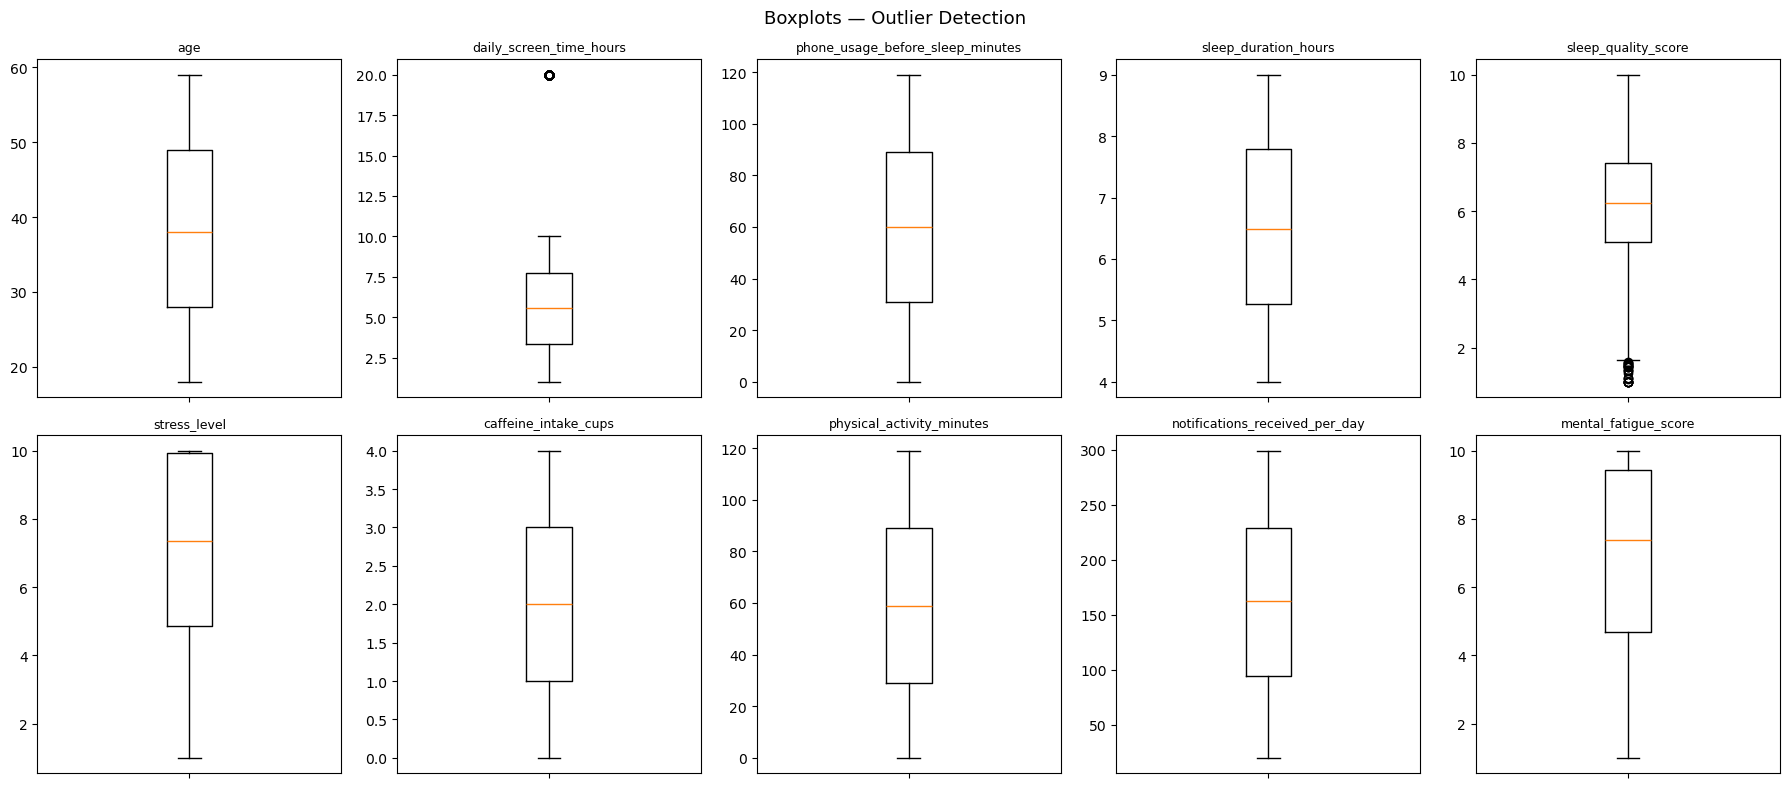

In [34]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(axis='x', labelbottom=False)

plt.suptitle('Boxplots — Outlier Detection', fontsize=13)
plt.tight_layout()
plt.show()

###
 Outlier Detection & Treatment

#### Method used:
IQR (Interquartile Range) method — flags values below Q1 - 1.5×IQR
or above Q3 + 1.5×IQR. Chosen over Z-score because behavioral data
(screen time, notifications) is right-skewed, not normally distributed.
Z-score assumes normality and would give misleading bounds here.

#### Findings:

daily_screen_time_hours — 137 outliers (0.95%) above IQR upper bound
of 14.34. Max value is 20.0 hours, which is domain-impossible (leaves
only 4 hours for sleep, meals, and all other activities). Treated by
capping at 14.34 (winsorization).

sleep_quality_score — 24 outliers near lower bound of 1.59. Min is 1.0
which is within the valid 1–10 scale. These are extreme but plausible
scores — retained as real signal.

All other columns — 0 IQR outliers detected. notifications_received
_per_day max of 299 appeared suspicious visually but falls well within
IQR bounds (upper: 431.5). No treatment needed.

#### Why winsorize instead of drop:
Dropping 137 rows removes real behavioral data from those users.
Capping replaces impossible values with the most extreme believable
value, preserving the row while eliminating the distortion.

In [35]:
# Cap daily_screen_time_hours at IQR upper bound
upper_bound = 14.34

before_max = df['daily_screen_time_hours'].max()
df['daily_screen_time_hours'] = df['daily_screen_time_hours'].clip(upper=upper_bound)
after_max = df['daily_screen_time_hours'].max()

print(f"daily_screen_time_hours max before capping: {before_max}")
print(f"daily_screen_time_hours max after capping:  {after_max}")
print(f"Values capped: {(df['daily_screen_time_hours'] == upper_bound).sum()}")

# Verify no new issues introduced
print(f"\nFinal describe for daily_screen_time_hours:")
print(df['daily_screen_time_hours'].describe().round(2))

daily_screen_time_hours max before capping: 20.0
daily_screen_time_hours max after capping:  14.34
Values capped: 137

Final describe for daily_screen_time_hours:
count    14402.00
mean         5.59
std          2.68
min          1.00
25%          3.36
50%          5.55
75%          7.75
max         14.34
Name: daily_screen_time_hours, dtype: float64


## **EDA & Visualizations:**

#### Distribution of Key Variables:

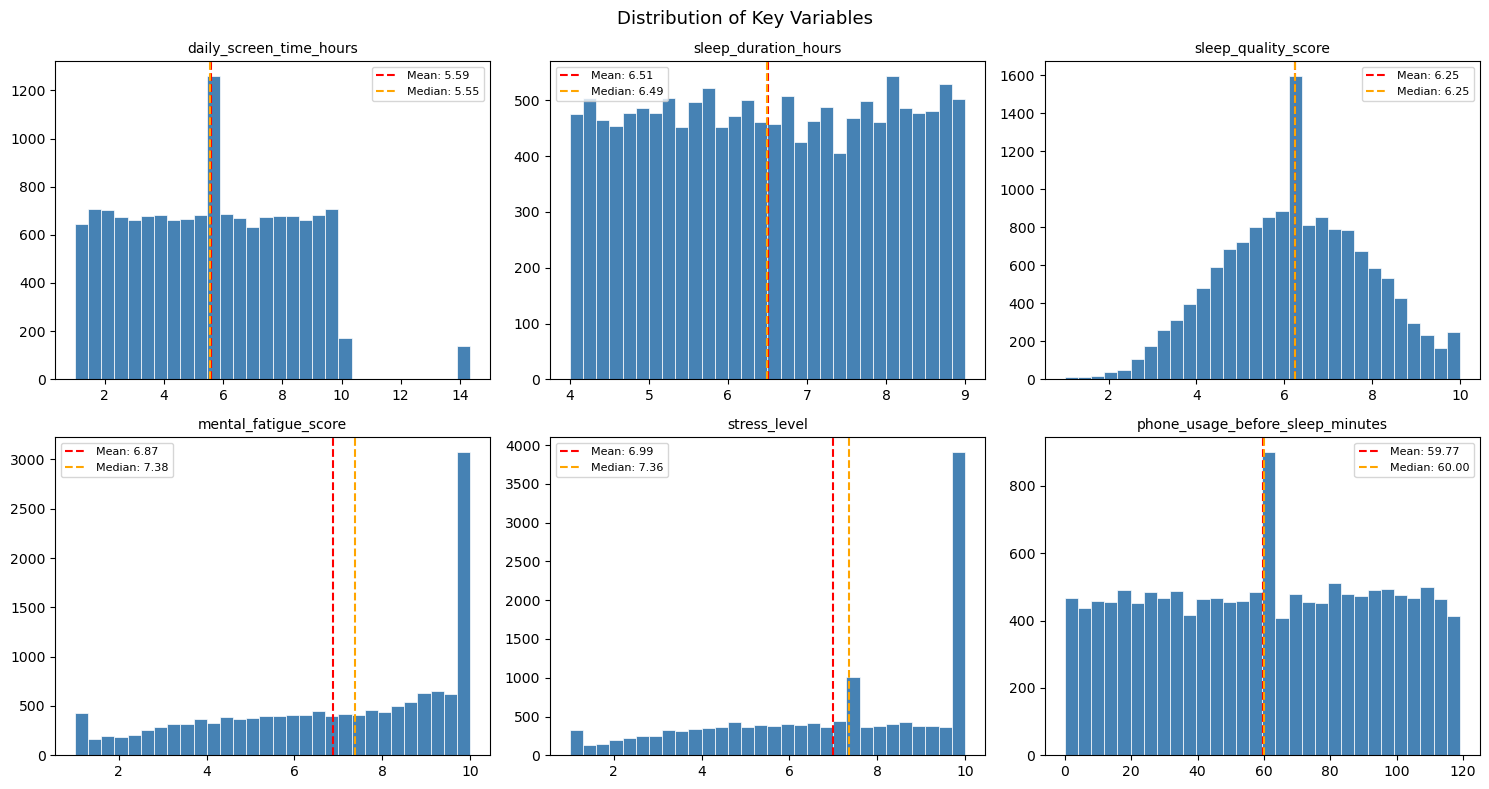

In [36]:
cols_to_plot = [
    'daily_screen_time_hours',
    'sleep_duration_hours', 
    'sleep_quality_score',
    'mental_fatigue_score',
    'stress_level',
    'phone_usage_before_sleep_minutes'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', 
                    linewidth=1.5, label=f'Mean: {df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='--', 
                    linewidth=1.5, label=f'Median: {df[col].median():.2f}')
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution of Key Variables', fontsize=13)
plt.tight_layout()
plt.show()

Most variables show uniform distributions indicating diverse user behavior.
mental_fatigue_score and stress_level are both left-skewed with mean < median
and a spike at 10.0, confirming most users experience high fatigue and stress.
Imputation artifacts are visible as spikes at median values (6.25, 60.0, 5.55).

#### Screen Time vs Sleep Quality:

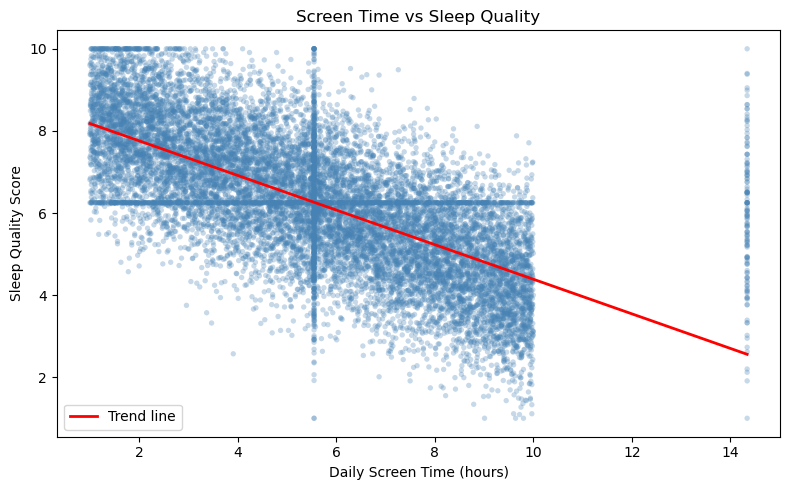

Pearson correlation: -0.6787


In [37]:
plt.figure(figsize=(8, 5))
plt.scatter(df['daily_screen_time_hours'], df['sleep_quality_score'],
            alpha=0.3, color='steelblue', edgecolors='none', s=15)

# Add trend line
z = np.polyfit(df['daily_screen_time_hours'], df['sleep_quality_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['daily_screen_time_hours'].min(), 
                    df['daily_screen_time_hours'].max(), 100)
plt.plot(x_line, p(x_line), color='red', linewidth=2, label='Trend line')

plt.xlabel('Daily Screen Time (hours)')
plt.ylabel('Sleep Quality Score')
plt.title('Screen Time vs Sleep Quality')
plt.legend()
plt.tight_layout()
plt.show()
# Print correlation
corr = df['daily_screen_time_hours'].corr(df['sleep_quality_score'])
print(f"Pearson correlation: {corr:.4f}")

Strong negative correlation of -0.68 confirms that higher daily screen time
directly associates with lower sleep quality. The trend line drops from ~8.2
to ~2.5 as screen time increases — the strongest single relationship found in EDA.

####  Phone Usage Before Sleep vs Mental Fatigue:

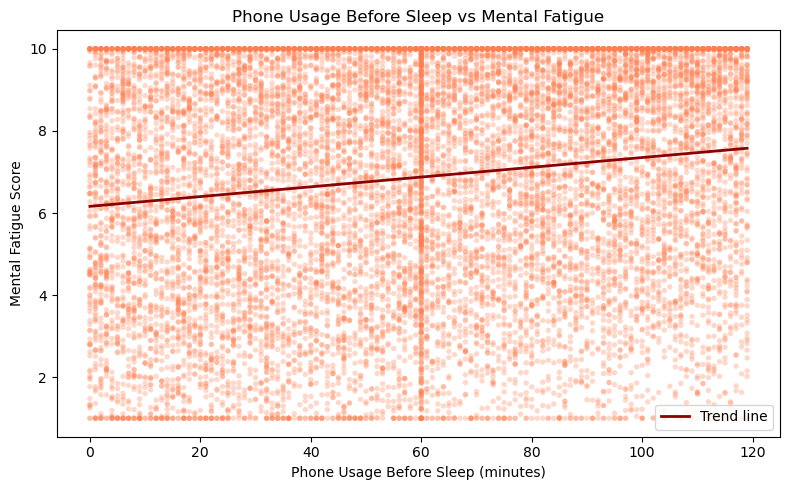

Pearson correlation: 0.1484


In [38]:
plt.figure(figsize=(8, 5))
plt.scatter(df['phone_usage_before_sleep_minutes'], df['mental_fatigue_score'],
            alpha=0.3, color='coral', edgecolors='none', s=15)

z = np.polyfit(df['phone_usage_before_sleep_minutes'], df['mental_fatigue_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['phone_usage_before_sleep_minutes'].min(),
                    df['phone_usage_before_sleep_minutes'].max(), 100)
plt.plot(x_line, p(x_line), color='darkred', linewidth=2, label='Trend line')

plt.xlabel('Phone Usage Before Sleep (minutes)')
plt.ylabel('Mental Fatigue Score')
plt.title('Phone Usage Before Sleep vs Mental Fatigue')
plt.legend()
plt.tight_layout()
plt.show()

corr2 = df['phone_usage_before_sleep_minutes'].corr(df['mental_fatigue_score'])
print(f"Pearson correlation: {corr2:.4f}")

Very weak positive correlation of +0.15 with a nearly flat trend line shows
that pre-sleep phone usage alone has minimal impact on mental fatigue.
Cumulative daily screen time is a far stronger predictor than timing before bed.

#### Stress & Fatigue by Occupation:

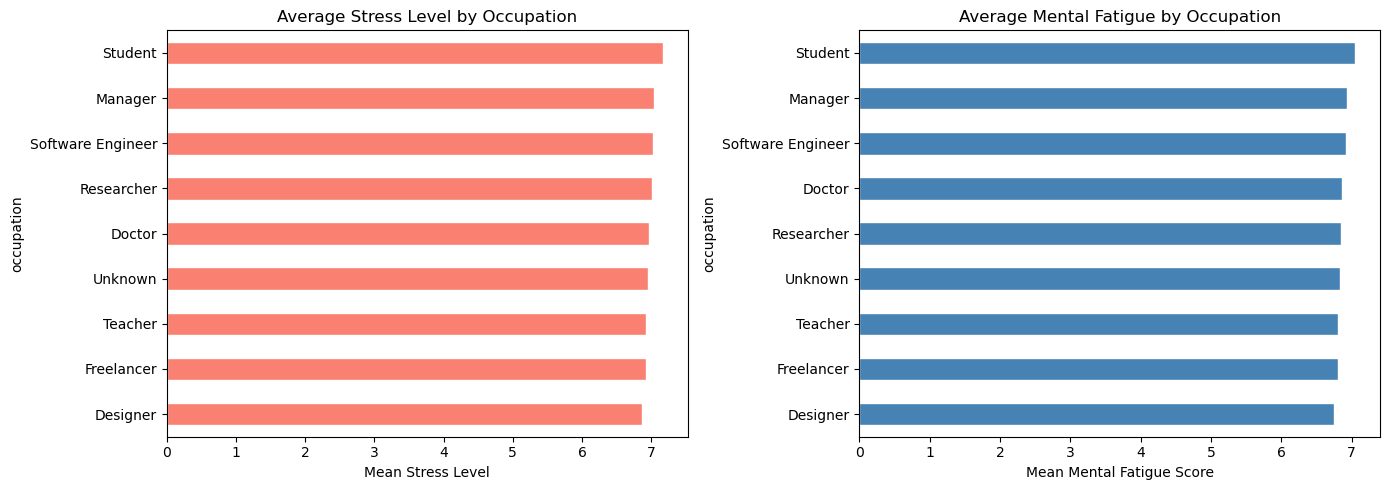

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average stress by occupation
stress_by_occ = df.groupby('occupation')['stress_level'].mean().sort_values(ascending=True)
stress_by_occ.plot(kind='barh', ax=axes[0], color='salmon', edgecolor='white')
axes[0].set_title('Average Stress Level by Occupation')
axes[0].set_xlabel('Mean Stress Level')

# Average fatigue by occupation
fatigue_by_occ = df.groupby('occupation')['mental_fatigue_score'].mean().sort_values(ascending=True)
fatigue_by_occ.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Average Mental Fatigue by Occupation')
axes[1].set_xlabel('Mean Mental Fatigue Score')

plt.tight_layout()
plt.show()

Students report highest stress and fatigue, Designers the lowest — but the
difference across all 9 occupations is only ~0.4 points on a 10-point scale.
Occupation is likely a weak predictor and may be deprioritized in Phase 2.

#### Correlation Heatmap:

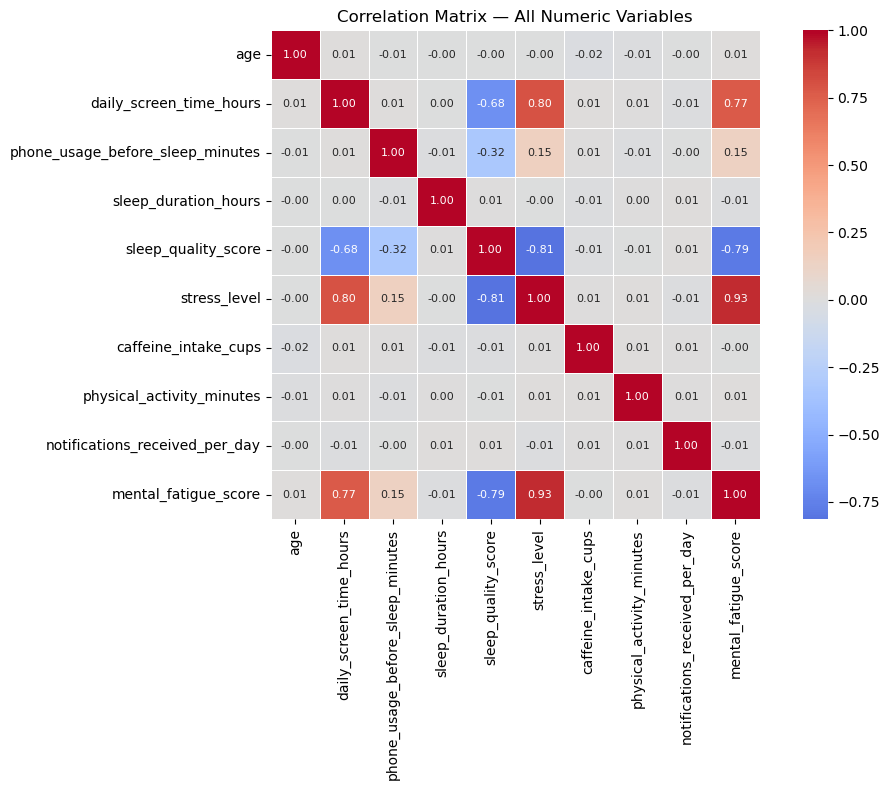

In [40]:
plt.figure(figsize=(11, 8))

numeric_cols = [
    'age', 'daily_screen_time_hours', 'phone_usage_before_sleep_minutes',
    'sleep_duration_hours', 'sleep_quality_score', 'stress_level',
    'caffeine_intake_cups', 'physical_activity_minutes',
    'notifications_received_per_day', 'mental_fatigue_score'
]

corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 8})

plt.title('Correlation Matrix — All Numeric Variables', fontsize=12)
plt.tight_layout()
plt.show()

Three strong relationships dominate: stress↔fatigue (0.93), screen time→stress
(0.80), and sleep quality→fatigue (-0.79). Age, sleep duration, caffeine,
physical activity, and notifications show near-zero correlations with the target.
stress_level flagged for multicollinearity risk (0.93 with target variable).

## **Feature Engineering:**

#### Creating Fatigue Category column

In [41]:
# Create fatigue category column for classification model
def categorize_fatigue(score):
    if score <= 4.0:
        return 'Low'
    elif score <= 7.0:
        return 'Medium'
    else:
        return 'High'

df['fatigue_category'] = df['mental_fatigue_score'].apply(categorize_fatigue)

print("Fatigue category distribution:")
print(df['fatigue_category'].value_counts())
print(f"\nPercentage breakdown:")
print((df['fatigue_category'].value_counts() / len(df) * 100).round(2))

Fatigue category distribution:
fatigue_category
High      7725
Medium    3939
Low       2738
Name: count, dtype: int64

Percentage breakdown:
fatigue_category
High      53.64
Medium    27.35
Low       19.01
Name: count, dtype: float64


High fatigue represents 53.64% of all
rows. A naive classifier predicting "High" for every row would
achieve 53.64% accuracy — this is our baseline that Phase 2
models must meaningfully exceed.

#### Deriving a new Feature

In [42]:
# Create screen to sleep ratio
df['screen_to_sleep_ratio'] = (
    df['daily_screen_time_hours'] / df['sleep_duration_hours']
).round(3)

print("Screen to sleep ratio — sample values:")
print(df['screen_to_sleep_ratio'].describe().round(3))

# Check correlation with target variable
corr = df['screen_to_sleep_ratio'].corr(df['mental_fatigue_score'])
print(f"\nCorrelation with mental_fatigue_score: {corr:.4f}")

Screen to sleep ratio — sample values:
count    14402.000
mean         0.906
std          0.496
min          0.118
25%          0.517
50%          0.853
75%          1.205
max          3.541
Name: screen_to_sleep_ratio, dtype: float64

Correlation with mental_fatigue_score: 0.6803


In [43]:
df.shape

(14402, 15)

In [44]:
df.head()

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score,fatigue_category,screen_to_sleep_ratio
0,1,56,Female,Designer,3.26,86.0,5.31,7.72,3.49,0,35,119.0,3.57,Low,0.614
1,2,46,Female,Teacher,1.85,32.0,7.36,9.70,3.01,0,16,299.0,1.91,Low,0.251
2,3,32,Male,Designer,3.04,107.0,4.50,6.38,5.03,0,17,21.0,6.05,Medium,0.676
3,4,25,Male,Software Engineer,9.00,60.0,6.68,5.53,10.00,0,3,220.0,9.92,High,1.347
4,5,38,Female,Teacher,3.52,56.0,7.57,6.69,6.71,4,92,167.0,5.99,Medium,0.465
